🚀 启动自动化参数空间扫描与退火监测...

🎯 U_C = 1.2      | R² = 0.72868 | 平均误差 = 17.7876 | 耗时: 0.9s
🎯 U_C = 1.4      | R² = 0.98611 | 平均误差 = 5.5631 | 耗时: 0.7s
🎯 U_C = 1.5      | R² = 0.99222 | 平均误差 = 4.1537 | 耗时: 0.8s
🎯 U_C = 1.5437   | R² = 0.98998 | 平均误差 = 4.6597 | 耗时: 0.8s
🎯 U_C = 1.55     | R² = 0.98576 | 平均误差 = 5.7023 | 耗时: 0.8s
🎯 U_C = 1.7548   | R² = 0.99044 | 平均误差 = 4.8281 | 耗时: 0.8s
🎯 U_C = 1.85     | R² = 0.99249 | 平均误差 = 4.0399 | 耗时: 0.8s
   ⚠️ 警告：该参数下复数特征值太少，黎曼能谱坍缩！
🎯 U_C = 2.0      | R² = 0.00000 | 平均误差 = 20.0000 | 耗时: 0.8s


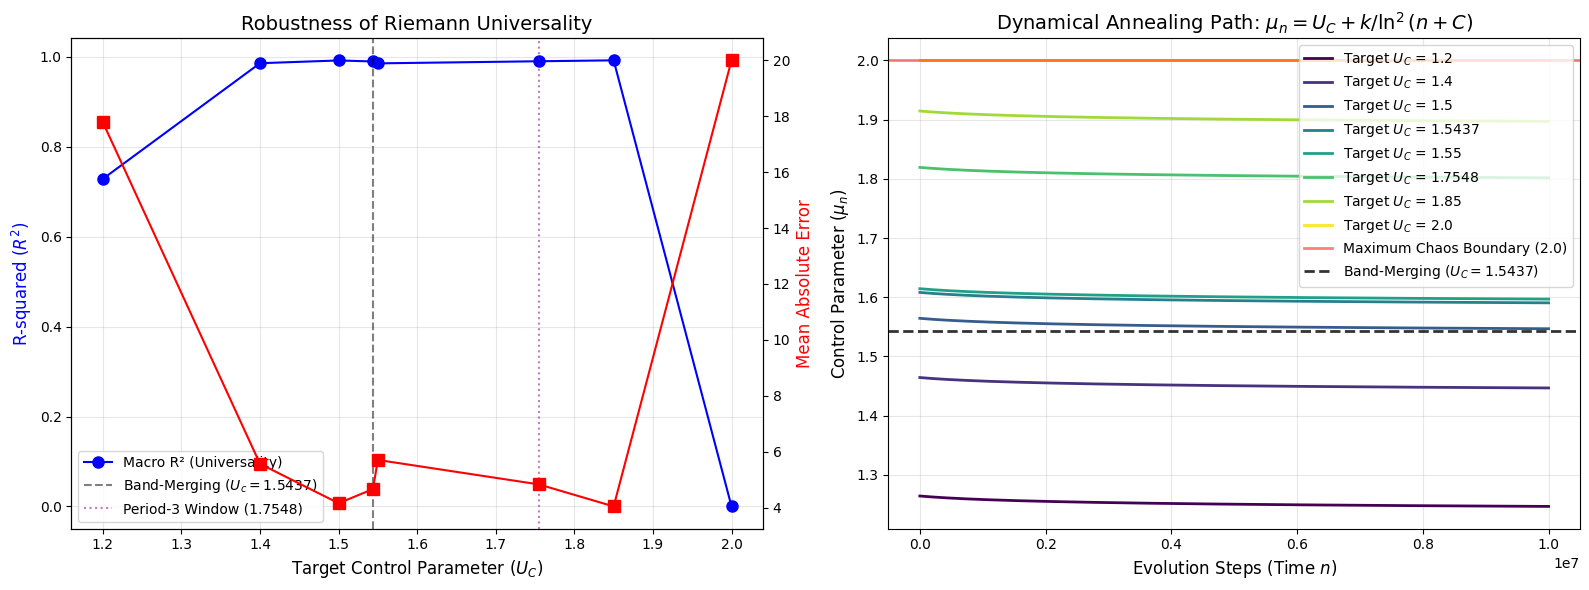

In [26]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.stats import linregress
import mpmath
import matplotlib.pyplot as plt
import time
from numba import njit

# 真实的黎曼零点
mpmath.mp.dps = 15
N_ZEROS = 100
TRUE_ZEROS = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_ZEROS + 1)])

@njit
def run_universe_with_tracker(steps, n_bins, u_c, k_opt):
    transitions = np.zeros((n_bins, n_bins), dtype=np.uint32)
    sample_points = 1000
    sample_rate = steps // sample_points
    mu_history = np.zeros(sample_points, dtype=np.float64)
    x = 0.5
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    sample_idx = 0
    
    for i in range(1, steps + 1):
        # 从右侧趋近，并保证不超过 2.0
        mu_raw = u_c + k_opt / (np.log(i + 10**6)**2)
        mu = min(mu_raw, 2.0) 
        
        if i % sample_rate == 0 and sample_idx < sample_points:
            mu_history[sample_idx] = mu
            sample_idx += 1
            
        x = 1.0 - mu * x * x
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        transitions[last_bin, current_bin] += 1
        last_bin = current_bin
        
    return transitions, mu_history

# 测试点
test_points = [1.2, 1.4, 1.50, 1.5437, 1.55, 1.7548, 1.85, 2.0]
results_R2 = []
results_mean_err = []
mu_trajectories = {}

total_steps = 10**7
K_OPT = 12.32 

print("🚀 启动自动化参数空间扫描与退火监测...\n")

for u in test_points:
    start_t = time.time()
    trans, mu_hist = run_universe_with_tracker(total_steps, 5000, u, K_OPT)
    mu_trajectories[u] = mu_hist
    
    P_sparse = sp.csr_matrix(trans, dtype=np.float64)
    row_sums = np.array(P_sparse.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0 
    P_sparse.data /= row_sums[P_sparse.indices]
    
    try:
        eigenvalues, _ = eigs(P_sparse, k=N_ZEROS + 20, which='LM', tol=1e-4)
        phases = np.sort(np.angle(eigenvalues[np.abs(eigenvalues.imag) > 1e-4]))
        unwrapped = np.unwrap(phases)
        
        # 🎯 【防崩溃核心逻辑】动态匹配长度
        min_len = min(len(unwrapped), N_ZEROS)
        
        if min_len > 10: # 如果至少还有10个有效特征值，勉强算一算
            unwrapped_trunc = unwrapped[:min_len]
            true_zeros_trunc = TRUE_ZEROS[:min_len]
            
            slope, intercept, r_val, _, _ = linregress(unwrapped_trunc, true_zeros_trunc)
            pred = slope * unwrapped_trunc + intercept
            
            err = np.mean(np.abs(pred - true_zeros_trunc))
            r2 = r_val**2
        else:
            # 物理意义：宇宙冷寂过头，没有波动，直接赋予最差评分
            err = 20.0 
            r2 = 0.0
            print("   ⚠️ 警告：该参数下复数特征值太少，黎曼能谱坍缩！")
            
    except Exception as e:
        err = 20.0
        r2 = 0.0
        print(f"   ⚠️ 警告：特征值提取失败 ({e})")
        
    results_R2.append(r2)
    results_mean_err.append(err)
    
    print(f"🎯 U_C = {u:<8} | R² = {r2:.5f} | 平均误差 = {err:.4f} | 耗时: {time.time()-start_t:.1f}s")

# ================= 绘图环节 =================
# 🎯 添加了 r 前缀修复转义字符警告

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1_twin = ax1.twinx()
ax1.plot(test_points, results_R2, 'b-o', markersize=8, label='Macro R² (Universality)')
ax1_twin.plot(test_points, results_mean_err, 'r-s', markersize=8, label='Micro Mean Error (Precision)')

ax1.axvline(1.543689, color='k', linestyle='--', alpha=0.5, label='Band-Merging ($U_c=1.5437$)')
ax1.axvline(1.7548, color='purple', linestyle=':', alpha=0.5, label='Period-3 Window (1.7548)')

ax1.set_xlabel(r'Target Control Parameter ($U_C$)', fontsize=12)
ax1.set_ylabel(r'R-squared ($R^2$)', color='b', fontsize=12)
ax1_twin.set_ylabel('Mean Absolute Error', color='r', fontsize=12)
ax1.set_title('Robustness of Riemann Universality', fontsize=14)
ax1.legend(loc='lower left')
ax1.grid(True, alpha=0.3)

time_steps = np.linspace(0, total_steps, 1000)
colors = plt.cm.viridis(np.linspace(0, 1, len(test_points)))

for i, u in enumerate(test_points):
    ax2.plot(time_steps, mu_trajectories[u], color=colors[i], lw=2, label=f'Target $U_C$ = {u}')

ax2.axhline(2.0, color='red', linestyle='-', lw=2, alpha=0.5, label='Maximum Chaos Boundary (2.0)')
ax2.axhline(1.543689, color='k', linestyle='--', lw=2, alpha=0.8, label='Band-Merging ($U_C=1.5437$)')

ax2.set_xlabel(r'Evolution Steps (Time $n$)', fontsize=12)
ax2.set_ylabel(r'Control Parameter ($\mu_n$)', fontsize=12)
ax2.set_title(r'Dynamical Annealing Path: $\mu_n = U_C + k / \ln^2(n+C)$', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
np.log(i + 10**6)

np.float64(13.815515557951775)

In [5]:
np.log( 10**7 + 10**6)

np.float64(16.213405830762646)

In [9]:
K_OPT / (np.log(0 + 10**6)**2)

np.float64(0.064547114088419)

In [10]:
K_OPT / (np.log( 10**7 + 10**6)**2)

np.float64(0.04686646539726034)

In [12]:
K_OPT / (np.log( 10**8 + 10**6)**2)

np.float64(0.03626855859253754)

In [18]:
K_OPT / (np.log( 10**12 + 10**12)**2)

np.float64(0.015356646082562946)

In [21]:
K_OPT / (np.log( float(10**20 + 10**12))**2)

np.float64(0.005809240265434788)

In [22]:
K_OPT / (np.log( float(10**30 + 10**12))**2)

np.float64(0.0025818845635367594)

In [23]:
K_OPT / (np.log( float(10**0 + 10**6))**2)

np.float64(0.06454710474427286)

In [27]:
K_OPT / (np.log( float(10**7 + 10**6))**2)

np.float64(0.04686646539726034)

In [28]:
K_OPT / (np.log( 0 + 10**6)**2)

np.float64(0.064547114088419)

In [29]:
K_OPT / (np.log( 10**7 + 10**6)**2)

np.float64(0.04686646539726034)